**Fundamentos de Data Science**

*Analizando la Rotación de Clientes en Telecomunicaciones*


Limpieza de datos con Python:
- Identificar y solucionar cualquier valor duplicado.
Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
- Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
- Identificar y solucionar cualquier valor faltante en el dataset.
- Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.
- Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).

Exploración de datos con Python:

- Crear dos tipos diferentes de visualizaciones exploratorias univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.
- Crear dos tipos diferentes de visualizaciones exploratorias multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
# Para corrborar que el df fue cargado exitosamente, se visualizan las primeras 5 columnas

df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Se usa la función info para obtener información general de la estructura del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# se identifica el tipo de dato de cada columna

print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
# Se usa la función describe para obtener ciertas estadísticas del dataset.
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [89]:
# Se buscan datos nulos en el dataset, los que quedan de forma NaN

df.isnull().sum()

#no se detectan valores nulos

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [91]:
#Indpendientemente que no tenga valores NaN el dataset, se revisa si los valores de cada columna tienen sentido, para lo que se buscan los valores únicos de cada coluumna

for columna in df.select_dtypes(include=object).columns:
    print(f"\n{columna}:")
    print(df[columna].value_counts())


customerID:
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No     4336
Yes    2707
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No     4999
Yes    2044
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No     4999
Yes    2044
Name: count, dtype: int64

TechSupport:
TechSupp

In [92]:
# Se identificó que celdas debían que tener nombre si/no, tenian otra forma de llamar a estos valores, por lo que se normaliza para sólo tener los valores si/no
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")
print(df["MultipleLines"].unique())
df["OnlineSecurity"] = df["OnlineSecurity"].replace("No internet service", "No")
print(df["OnlineSecurity"].unique())
df["OnlineBackup"] = df["OnlineBackup"].replace("No internet service", "No")
print(df["OnlineBackup"].unique())
df["DeviceProtection"] = df["DeviceProtection"].replace("No internet service", "No")
print(df["DeviceProtection"].unique())
df["TechSupport"] = df["TechSupport"].replace("No internet service", "No")
print(df["TechSupport"].unique())
df["StreamingTV"] = df["StreamingTV"].replace("No internet service", "No")
print(df["StreamingTV"].unique())
df["StreamingMovies"] = df["StreamingMovies"].replace("No internet service", "No")
print(df["StreamingMovies"].unique())

['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']


In [93]:
# Tambiéb, se detecta que hay 11 espacios vacíos en "TotalChargues del df"
df.isin([" "]).sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [95]:
# Considerando que el dataset tiene 7043 registros y hay sólo 11 nulos (0,15% del total) sería válido eliminar  los registros o bien rellenarlos, en ambos casos se no afecta la integridad de los datos.
len(df)

7043

In [98]:
# Pero a tes de modificarlo es necesario pasar los valores de objeto a número
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(round(df["TotalCharges"].mean()))

2283


In [99]:
# Se reemplazan los valores con espacios por el primedio del gasto
df["TotalCharges"].fillna(df["TotalCharges"].mean())

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [101]:
# Se confirma que los 11 valores desaparecieron :D
df.isin([" "]).sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Análisis Univariable**
- Se analiza la distribución del cargo mensual de los clientes, ya que permite visualizar de forma eficiente en que tramo de precio se concentran los clientes. De acuerdo al resultado, es claro que una gran cantidad de clientes paga el mínimo, es decir, tiene sólo 1 servicio contradado y el segundo tramo más relevante es entre 50 y 80 USD, por lo que se podría analizar la diferencia entre estos dos tipos de cliente para ofrecer mejores opciones a quienes sólo tienen el servicio básico.

Text(0, 0.5, 'Cantidad de Clientes')

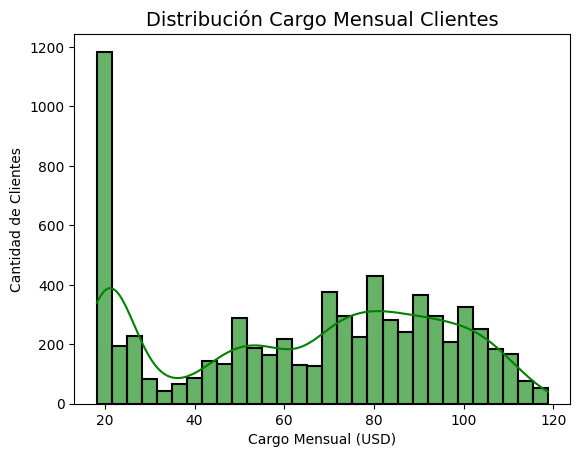

In [102]:
# Luego, se comienza con los visualiaciones univariables
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="green", alpha=0.6, linewidth=1.5)
plt.title("Distribución Cargo Mensual Clientes", fontsize=14)
plt.xlabel("Cargo Mensual (USD)", fontsize=10)
plt.ylabel("Cantidad de Clientes", fontsize=10)



Text(0, 0.5, 'Cargo Mensual')

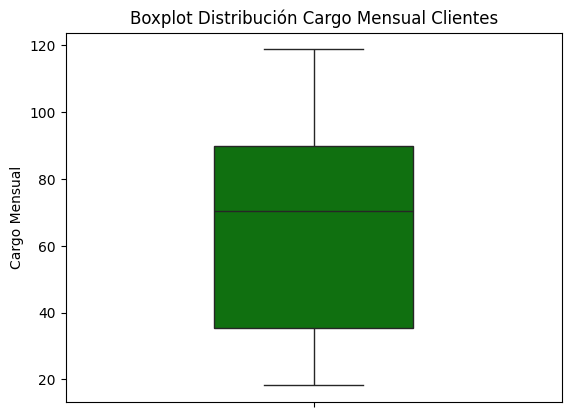

In [103]:
# se realiza un boxplot para buscar outliers pero no se detectan valores fuera de lo común.
sns.boxplot(data=df, y="MonthlyCharges", width=0.4, color="green")
plt.title("Boxplot Distribución Cargo Mensual Clientes", fontsize=12)
plt.ylabel("Cargo Mensual", fontsize=10)

**Análisis Univariable**
- Se revisa el método de pago preferido por los clientes, en general, la distribuciónes homogénea, existiendo una diferencia en favor de la tranferencia directa.

Text(0.5, 0, 'Cantidad Clientes')

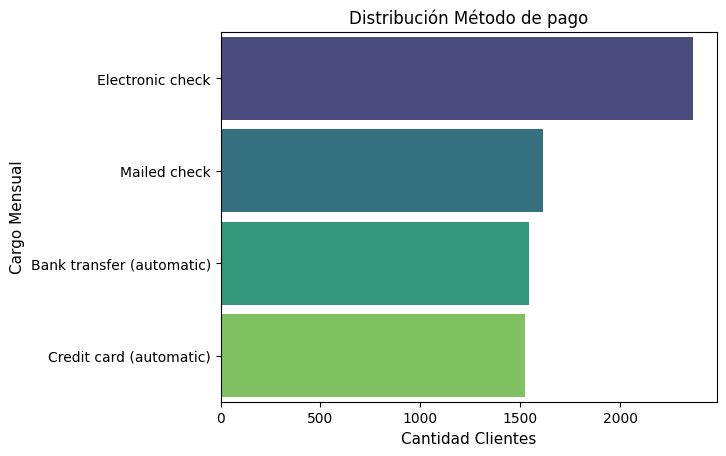

In [22]:
sns.countplot(data=df, y="PaymentMethod",  hue="PaymentMethod", palette="viridis", width=0.9, legend=False)
plt.title("Distribución Método de pago", fontsize=12)
plt.ylabel("Cargo Mensual", fontsize=11)
plt.xlabel("Cantidad Clientes", fontsize=11)

**Análisis Multivariable**

Este análisis permite visualizar el tiempo de permanencia, pago mensual y la renuncia de clientes. A partir del gráfico, es claro que hay una mayor concentración de renuncias en los primeros 10 meses de contratado el servicio, más aún, cuando pagan montos superiores a 80 USD. Al transcurrir el tiempo, los clientes que más renuncian también son aquellos que pagan montos más altos, mientras que quienes pagan el mínimo se mantienen relativamente estables en el tiempo. También, resulta interesante observar que hay una densidad mucho menor de clientes en el tramo de 20 a 40 USD, lo que también se observa en el gráfico de distribución de clientes anterior, esto podría ser un indicio que no hay planes atractivos para ese tramo y por lo tanto, es una oportunidad de subir de nivel a los clientes que están en el rango mínimo.

Finalmente, este análisis permite al negocio enfocar sus esfuerzos en la fidelización de clientes que contratan más servicios, sobre todo en los primeros meses.





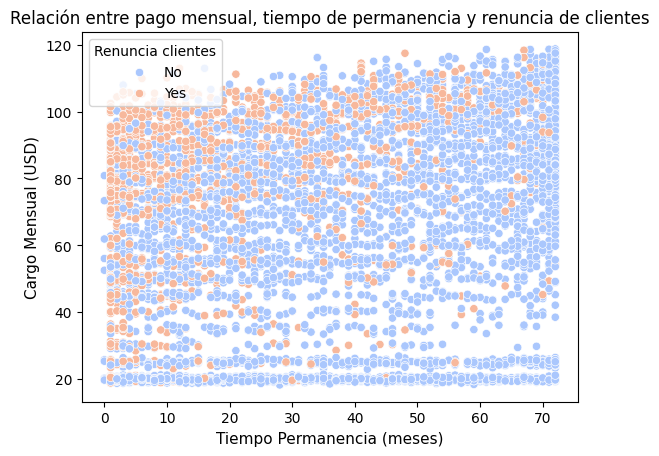

In [42]:
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", palette="coolwarm")
plt.title("Relación entre pago mensual, tiempo de permanencia y renuncia de clientes", fontsize=12)
plt.ylabel("Cargo Mensual (USD)", fontsize=11)
plt.xlabel("Tiempo Permanencia (meses)", fontsize=11)
plt.legend(title="Renuncia clientes")

**Análisis Multivariable**

En este gráfico se observa la relación entre el número de servicios contratado por cliente y la renuncia a la compañia. Esto permite visualizar en general cuantos servicios contrata cada clientes y a su vez, saber qué clientes son mas propensos a renunciar. Es claro, que los clientes que más renuncian son aquellos que sólo tienen un servicio, seguido de quienes tienen 5, 4 y 2 quedando bastante por detrás quienes tienen 6 y 7. Dada la logística que implica abandonar la compañía de telecomunaciones resulta lógico que quienes tienen más servicios abandonen menos, por lo que el enfoque debería ir en retener y fidelizar a los clientes nuevos que contratan su primer servicio probablemente para probar la compañía.

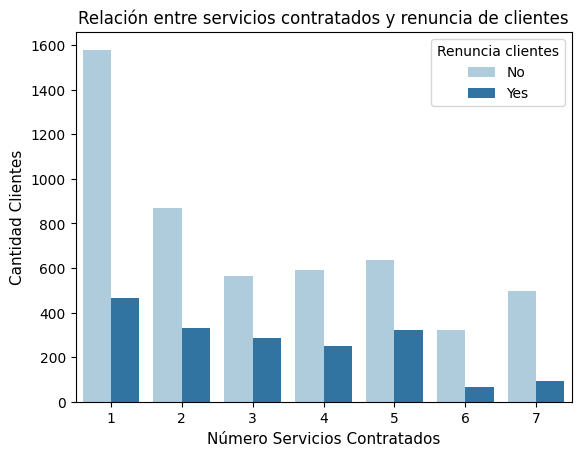

In [111]:
# Se crea una losta con los servicios de la empresa

servicios = ["PhoneService", "MultipleLines", "InternetService",
             "OnlineSecurity", "OnlineBackup", "TechSupport",
             "StreamingTV", "StreamingMovies"]

# Se calcula el total de servicios por cliente

df["total_servicios"] = df[servicios].apply(lambda x: (x == "Yes").sum(), axis=1)
df = df[df["total_servicios"] > 0].copy()
sns.countplot(data=df, x="total_servicios", hue="Churn", palette="Paired")
plt.title("Relación entre servicios contratados y renuncia de clientes", fontsize=12)
plt.ylabel("Cantidad Clientes", fontsize=11)
plt.xlabel("Número Servicios Contratados", fontsize=11)
plt.legend(title="Renuncia clientes")

